In [4]:
#import this
a = 7
def f():
    global a
    a = a + 1
    return a

print(f())

8


In [5]:
a = "globalna"
def f1():
    global a
    a = "f1"
    def f2():
        a = "f2"
        def f3():
            nonlocal a
            a = "f3"
            print(f"wartosc w f3: {a}")
        f3()
        print(f"wartosc w f2: {a}")
    f2()
    print(f"wartosc w f1: {a}")
f1()
print(f"wartosc globalna: {a}")

wartosc w f3: f3
wartosc w f2: f3
wartosc w f1: f1
wartosc globalna: f1


In [9]:
def outer():
    if False:
        x = 10

    def inner():
        nonlocal x
        x = 1232

    inner()
    print(x)


outer()

1232


In [14]:
def f():
    a = 7
    locals()["a"] = 8
    print(a)
    print(id(globals()) == id(locals() ))

f()


7
False
True


In [15]:
def factory(n):
    def inner():
        print(str(list(range(n)))[1:-1])

    return inner


wypisz = factory(6)
wypisz()
wypisz.__closure__[0].cell_contents = 15
wypisz()

0, 1, 2, 3, 4, 5
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14


In [37]:
def closure_test():
    lst = []
    for i in range(3):
        lst.append(lambda i=i: print(i))
    for f in lst:
        f()


closure_test()

0
1
2


In [45]:
def raport(func):
    print("nazwa funkcji:", func.__name__)
    print("liczba argumentów:", func.__code__.co_argcount)
    print("Nazwy zmiennych lokalnych:", func.__code__.co_varnames)
    print("Globalne:", func.__code__.co_names)

In [46]:
def licznik():
    x = 0
    def func():
        nonlocal x
        x = x + 1
        return x
    return func

a = licznik()
print(a())
print(a())

raport(a)

1
2
nazwa funkcji: func
liczba argumentów: 0
Nazwy zmiennych lokalnych: ()
Globalne: ()


In [48]:
def utworz_konto(stan_poczatkowy):
    x = stan_poczatkowy
    def wplac(kwota):
        nonlocal x
        return x + kwota
    def wyplac(kwota):
        nonlocal x
        if (x - kwota) < 0:
            return 0
        else:
            return x - kwota

    return wplac,wyplac


y = utworz_konto(1000)
y[0](250)
raport(y[0])

nazwa funkcji: wplac
liczba argumentów: 1
Nazwy zmiennych lokalnych: ('kwota',)
Globalne: ()


In [47]:
g = 1.1

def funkcja(p1, p2):
    z = p1 + p2
    u = p1 - p2
    return u * z * g

print("globalne:", funkcja.__code__.co_names)
print("liczba parametrów:", funkcja.__code__.co_argcount)
print("lokalne (w tym parametry):", funkcja.__code__.co_varnames)

globalne: ('g',)
liczba parametrów: 2
lokalne (w tym parametry): ('p1', 'p2', 'z', 'u')


In [50]:
type(type)

type

In [ ]:
class my_int(int):

    def __init__(self,arg = 0):
        self 

In [77]:
class Produkt():
    def __init__(self, name="!", price=0):
        self.nazwa = name
        self.cena = price

    def zastosuj_rabat(self,procent = 100):
        self.cena = (self.cena * procent) / 100


zeszyt = Produkt("zeszyt",50)
print(zeszyt.cena)
zeszyt.zastosuj_rabat(50)
print(zeszyt.cena)

50
25.0


In [70]:
class Pracownik():
    ilosc = 0
    def __init__(self,name="!"):
        self.imie = name
        self.id = Pracownik.ilosc
        Pracownik.ilosc += 1

pracownicy = []
for i in range(5):
    pracownicy.append(Pracownik(f"{i}_imie"))

for worker in pracownicy:
    print(f"{worker.imie} {worker.id}")

0_imie 0
1_imie 1
2_imie 2
3_imie 3
4_imie 4


In [82]:
class Pudelko:
    pass

def zapelnij_pudelko(pudelko, slownik):
    for key,value in slownik.items():
        setattr(pudelko,key,value)
        #print(key,value)

a = Pudelko()
s = {"name": "p", "att": 10}

zapelnij_pudelko(a,s)



10


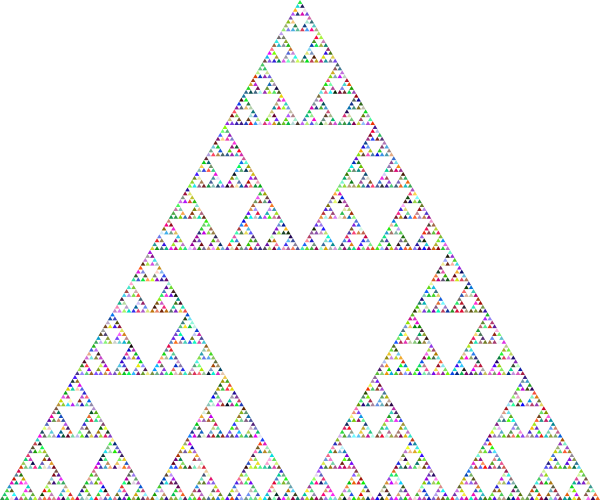

In [100]:
from IPython.display import SVG
import random
class Trojkat:
    """Klasa reprezentujaca jeden trojkat."""
   
    def __init__(self, punkt1, punkt2, punkt3):
       self.p1 = punkt1
       self.p2 = punkt2
       self.p3 = punkt3
    def __str__(self):
        return f"Trojkat: {self.p1}, {self.p2}, {self.p3}."

    def podziel(self):
        def punkt_podzialu(p1,p2):
            return [(p1[0] + p2[0]) / 2,  (p1[1] + p2[1]) / 2]

        q1 = punkt_podzialu(self.p1, self.p2)
        q2 = punkt_podzialu(self.p1, self.p3)
        q3 = punkt_podzialu(self.p2, self.p3)        
        return [Trojkat(self.p1, q1, q2), Trojkat(q1, self.p2, q3), 
                Trojkat(q2, q3, self.p3)]

    def __str__(self):
       r = random.randint(0, 255)
       g = random.randint(0, 255)
       b = random.randint(0, 255)
       return (r'<polygon points="{},{} {},{} {},{}"'
               ' style="fill:rgb({}, {}, {});"/>').format(
                 self.p1[0], self.p1[1], 
                 self.p2[0], self.p2[1], 
                 self.p3[0], self.p3[1],
                 r,g,b)


def zbuduj_fraktal(trojkat, liczba_poziomow, size=None):
  trojkaty = [trojkat]
                                            
  for i in range(liczba_poziomow): 
    trojkaty = sum([t.podziel() for t in trojkaty], [])
    
  siz = "" if size is None else f'width="{size[0]}" height="{size[1]}" '
  header = f'<svg xmlns="http://www.w3.org/2000/svg" {siz}version="1.1">\n'
   
  return header + "\n".join([str(t) for t in trojkaty]) + '\n</svg>'

s = zbuduj_fraktal(Trojkat([0, 500], [300, 0], [600, 500]), 7, (600,500))
SVG(s)


